# EDA 02 — Train Moments

**Data source**: `train-moments` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_train_moment_files()` + `parse_train_moments()`  
**Output**: `data/processed/train_moments_clean.parquet`

This notebook explores the raw train movement records before any spatial join with road closures. Train moments capture real-time observations of trains at locations: arrivals, departures, and passing events with both planned and actual timestamps. Understanding this source independently reveals the baseline operational characteristics of rail services, data quality, and the natural delay distribution before any road-closure conditioning.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Event type and variation status distributions  
4. Raw delay (timetable_variation) distribution  
5. Temporal distribution of movements  
6. Station code coverage (STANOX match rate)  
7. Operational flags (is_delayed, delay_monitoring_point, train_terminated)  
8. Platform, route and direction distributions  
9. Save cleaned output  


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_02", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

## 1. Load and Inspect Raw Data

In [2]:
from datetime import datetime, timezone
from src.data_loader import load_train_moment_files, parse_train_moments

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 12, 23, 59, 59, tzinfo=timezone.utc)

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

train_files = load_train_moment_files(START, END)
print(f"Files retrieved: {len(train_files)}")

raw_df = parse_train_moments(train_files, stations_reference_df)
print(f"Raw shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

Using 360 local files within the time window.
Files retrieved: 719
Skipping empty CSV file: data\train\train_data_20260410_204114.csv
Raw shape: (82273, 32)
Columns: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'station_code']


In [3]:
# Drop road-closure columns that leaked into train-moment blobs
drop_cols = [
    "situation_id", "record_id", "start_time", "end_time",
    "validity_status", "cause_type", "source", "road_name",
    "lanes_closed", "closure_lat", "closure_lon", "poslist", "ingestion_time",
]
raw_df = raw_df.drop(
    columns=[c for c in drop_cols if c in raw_df.columns]
)
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82273 entries, 0 to 82272
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   train_id                82196 non-null  str           
 1   actual_timestamp        78821 non-null  datetime64[ms]
 2   planned_timestamp       77868 non-null  datetime64[ms]
 3   gbtt_timestamp          52502 non-null  datetime64[ms]
 4   loc_stanox              79129 non-null  float64       
 5   next_stanox             74713 non-null  float64       
 6   event_type              78821 non-null  str           
 7   planned_event_type      78821 non-null  str           
 8   variation_status        78821 non-null  str           
 9   timetable_variation     78821 non-null  float64       
 10  platform                50688 non-null  object        
 11  route                   74159 non-null  object        
 12  direction               67488 non-null  str           
 1

In [4]:
raw_df.head()

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1.775811e+12,SDR,0.0,GGJ
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1.775811e+12,SMART,0.0,RYH
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1.775811e+12,SMART,0.0,BMD
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1.775811e+12,SMART,0.0,LHS
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1.775811e+12,SMART,1.0,WST


In [5]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
train_id,82196,38122,841S51MK10,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_timestamp,78821,NaN,NaN,NaN,2026-04-12 20:29:14.915000,2026-04-03 23:44:00,2026-04-10 21:49:00,2026-04-12 23:55:00,2026-04-13 23:31:00,2026-04-15 11:56:00,NaN
planned_timestamp,77868,NaN,NaN,NaN,2026-04-12 20:26:36.880000,2026-04-03 23:56:00,2026-04-10 21:47:30,2026-04-12 23:54:30,2026-04-13 23:30:00,2026-04-15 13:14:30,NaN
gbtt_timestamp,52502,NaN,NaN,NaN,2026-04-12 20:33:01.803000,2026-04-03 23:56:00,2026-04-10 21:44:00,2026-04-12 23:54:00,2026-04-13 23:32:00,2026-04-15 12:11:00,NaN
loc_stanox,79129.0,NaN,NaN,NaN,57969.39682,750.0,36515.0,65036.0,86461.0,89743.0,27658.12644
next_stanox,74713.0,NaN,NaN,NaN,57932.452853,750.0,36401.0,65023.0,86495.0,89743.0,27665.685485
event_type,78821,2,DEPARTURE,47510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
planned_event_type,78821,3,DEPARTURE,47510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variation_status,78821,4,LATE,31855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timetable_variation,78821.0,NaN,NaN,NaN,2.572081,0.0,0.0,1.0,2.0,293.0,7.674185


## 2. Missing Value Audit

The two most critical fields for the main analysis are `actual_timestamp` and `planned_timestamp`. Missing values in these fields prevent delay computation and cause rows to be dropped by the filtering pipeline.

In [6]:
missing = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().sum() / len(raw_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                        missing_count  missing_pct
platform                        31585        38.39
gbtt_timestamp                  29771        36.19
station_code                    22139        26.91
direction                       14785        17.97
route                            8114         9.86
next_stanox                      7560         9.19
planned_timestamp                4405         5.35
delay_monitoring_point           3452         4.20
actual_timestamp                 3452         4.20
variation_status                 3452         4.20
event_type                       3452         4.20
planned_event_type               3452         4.20
timetable_variation              3452         4.20
train_terminated                 3452         4.20
loc_stanox                       3144         3.82
data_source                       188         0.23
train_id                           77         0.09
msg_timestamp                      77         0.09
is_delayed                     

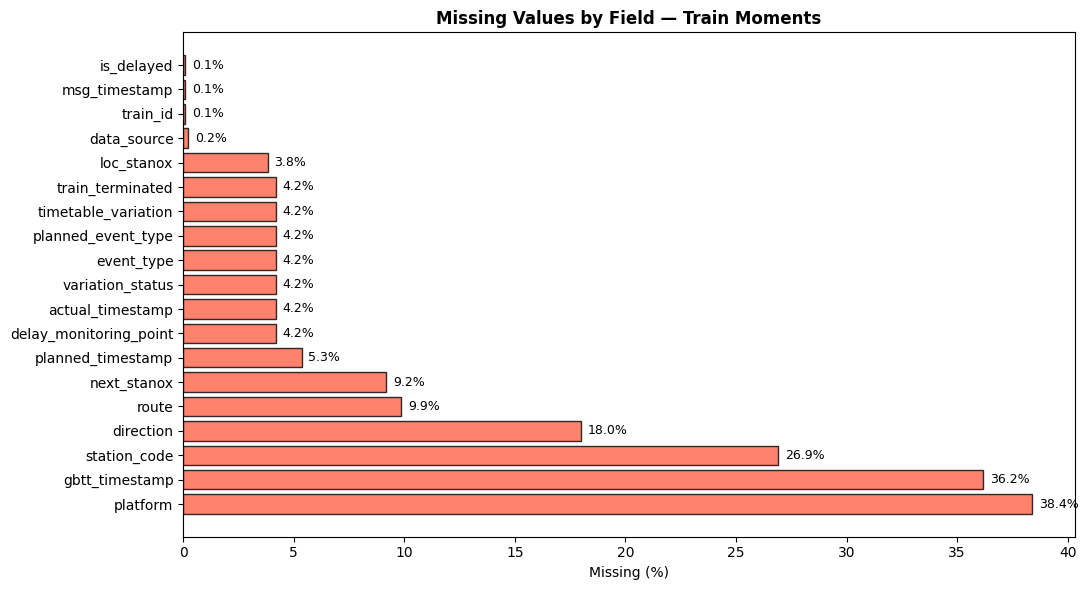

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field — Train Moments", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_02/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:
# Critical field missingness breakdown
print("actual_timestamp missing:  ", raw_df["actual_timestamp"].isna().sum(),
      f"({raw_df['actual_timestamp'].isna().mean()*100:.1f}%)")
print("planned_timestamp missing: ", raw_df["planned_timestamp"].isna().sum(),
      f"({raw_df['planned_timestamp'].isna().mean()*100:.1f}%)")
print("Both missing:              ",
      (raw_df["actual_timestamp"].isna() & raw_df["planned_timestamp"].isna()).sum())
print("Either missing:            ",
      (raw_df["actual_timestamp"].isna() | raw_df["planned_timestamp"].isna()).sum())

actual_timestamp missing:   3452 (4.2%)
planned_timestamp missing:  4405 (5.4%)
Both missing:               3452
Either missing:             4405


## 3. Event Type and Variation Status

In [9]:
print("=== Event Type ===")
et = raw_df["event_type"].value_counts()
print(et.to_string())
print()

print("=== Planned Event Type ===")
if "planned_event_type" in raw_df.columns:
    pet = raw_df["planned_event_type"].value_counts()
    print(pet.to_string())

=== Event Type ===
event_type
DEPARTURE    47510
ARRIVAL      31311

=== Planned Event Type ===
planned_event_type
DEPARTURE      47510
ARRIVAL        28418
DESTINATION     2893


In [10]:
print("=== Variation Status ===")
vs = raw_df["variation_status"].value_counts()
print(vs.to_string())

=== Variation Status ===
variation_status
LATE         31855
ON TIME      26578
EARLY        19435
OFF ROUTE      953


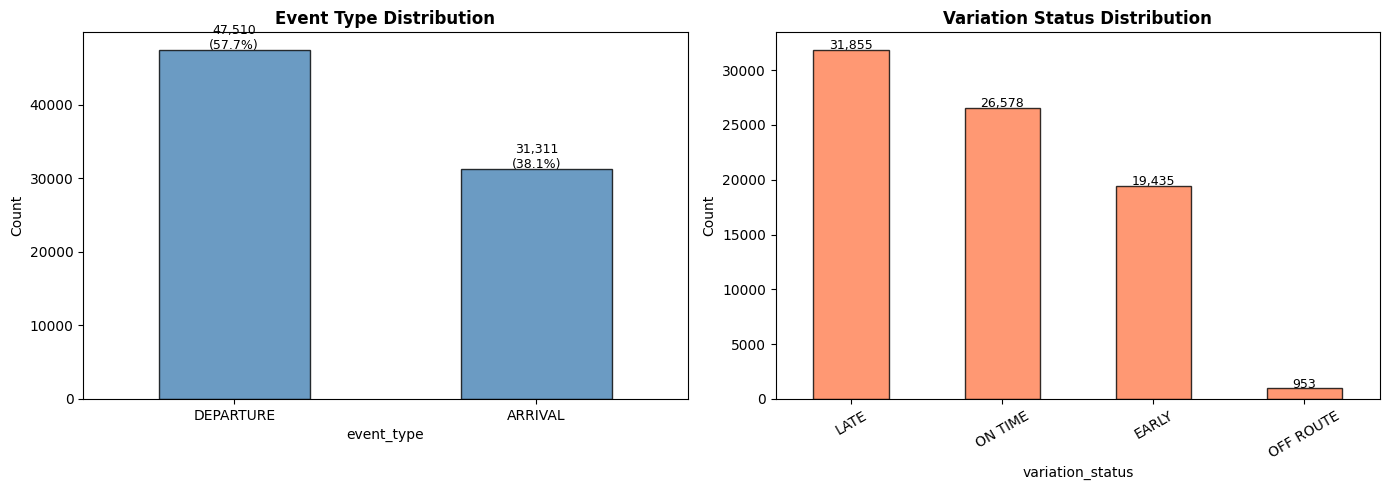

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

et.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Event Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(raw_df)*100:.1f}%)",
                 ha="center", fontsize=9)

vs.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Variation Status Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_02/event_variation.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
# Cross tab: event type vs variation status
if "variation_status" in raw_df.columns:
    ct = pd.crosstab(raw_df["event_type"], raw_df["variation_status"], margins=True)
    print(ct.to_string())

variation_status  EARLY   LATE  OFF ROUTE  ON TIME    All
event_type                                               
ARRIVAL            7701  12954        371    10285  31311
DEPARTURE         11734  18901        582    16293  47510
All               19435  31855        953    26578  78821


## 4. Raw Delay Distribution (timetable_variation)

`timetable_variation` is the raw delay in minutes as reported in the train moments feed — this is the delay BEFORE any road-closure conditioning. It represents the natural delay distribution of UK rail services across the observation period.

In [13]:
if "timetable_variation" in raw_df.columns:
    tv = raw_df["timetable_variation"].dropna()
    print("timetable_variation statistics:")
    print(tv.describe().round(2))
    print(f"\nSkewness: {tv.skew():.3f}")
    print(f"Kurtosis: {tv.kurtosis():.3f}")
    print(f"\nQuantiles:")
    print(tv.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

timetable_variation statistics:
count    78821.00
mean         2.57
std          7.67
min          0.00
25%          0.00
50%          1.00
75%          2.00
max        293.00
Name: timetable_variation, dtype: float64

Skewness: 12.900
Kurtosis: 279.962

Quantiles:
0.01     0.0
0.05     0.0
0.25     0.0
0.50     1.0
0.75     2.0
0.95    10.0
0.99    31.0
Name: timetable_variation, dtype: float64


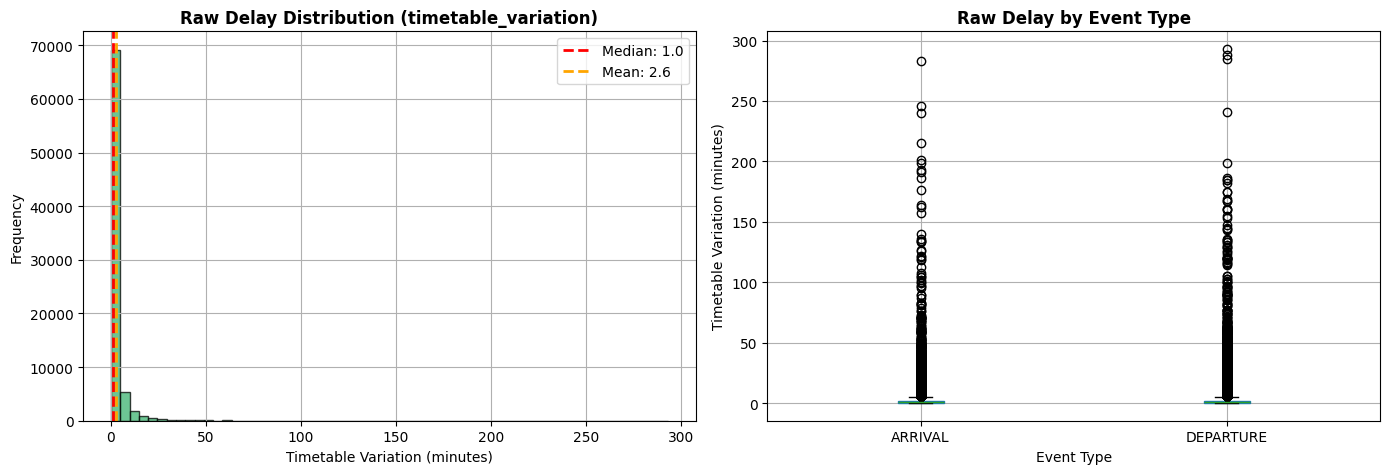

In [14]:
if "timetable_variation" in raw_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tv = raw_df["timetable_variation"].dropna()

    tv.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
    axes[0].axvline(tv.median(), color="red", linestyle="--", lw=2,
                    label=f"Median: {tv.median():.1f}")
    axes[0].axvline(tv.mean(), color="orange", linestyle="--", lw=2,
                    label=f"Mean: {tv.mean():.1f}")
    axes[0].set_xlabel("Timetable Variation (minutes)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Raw Delay Distribution (timetable_variation)", fontweight="bold")
    axes[0].legend()

    raw_df.boxplot(column="timetable_variation", by="event_type", ax=axes[1],
                   patch_artist=True)
    axes[1].set_title("Raw Delay by Event Type", fontweight="bold")
    axes[1].set_xlabel("Event Type")
    axes[1].set_ylabel("Timetable Variation (minutes)")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_02/raw_delay_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Temporal Distribution of Movements

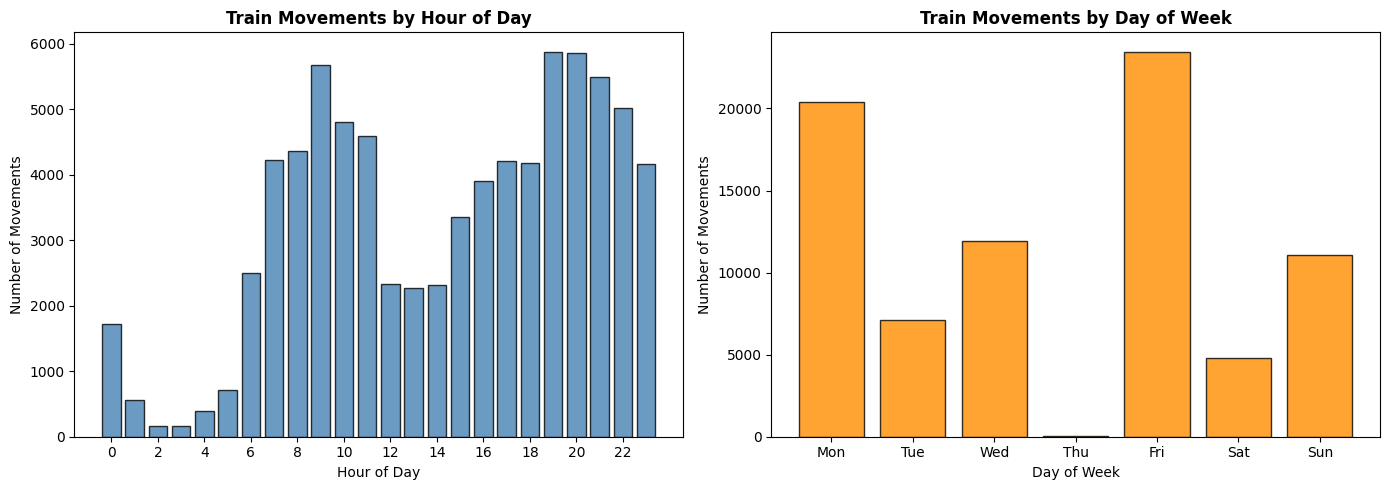

In [15]:
raw_df["actual_hour"] = raw_df["actual_timestamp"].dt.hour
raw_df["actual_dow"]  = raw_df["actual_timestamp"].dt.dayofweek
raw_df["actual_date"] = raw_df["actual_timestamp"].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = raw_df["actual_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Movements")
axes[0].set_title("Train Movements by Hour of Day", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_counts = raw_df["actual_dow"].value_counts().sort_index()
axes[1].bar([dow_map.get(i, str(i)) for i in dow_counts.index],
            dow_counts.values, color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Movements")
axes[1].set_title("Train Movements by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_02/temporal_movements.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# Day-level summary
print("Movements by date:")
print(raw_df["actual_date"].value_counts().sort_index().to_string())

Movements by date:
actual_date
2026-04-03        1
2026-04-08        1
2026-04-09       65
2026-04-10    23466
2026-04-11     4804
2026-04-12    11094
2026-04-13    20381
2026-04-14     7101
2026-04-15    11908


## 6. Station Code Coverage (STANOX Match Rate)

In [17]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    total   = len(raw_df)
    print(f"Total movements:              {total:,}")
    print(f"With station code matched:    {matched.sum():,} ({matched.mean()*100:.1f}%)")
    print(f"Without station code:         {(~matched).sum():,} ({(~matched).mean()*100:.1f}%)")
    print()

    # Station code distribution (top 20)
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)
    print("Top 20 station codes by movement count:")
    print(top_stations.to_string())

Total movements:              82,273
With station code matched:    60,134 (73.1%)
Without station code:         22,139 (26.9%)

Top 20 station codes by movement count:
station_code
CLJ    485
LBG    319
VXH    257
SRA    225
NXG    201
ECR    194
WIM    192
EAL    189
BET    188
HAY    183
STL    178
PUR    171
WAE    170
IFD    169
FPK    169
BAL    166
RMF    161
NEM    159
GDP    159
BHM    158


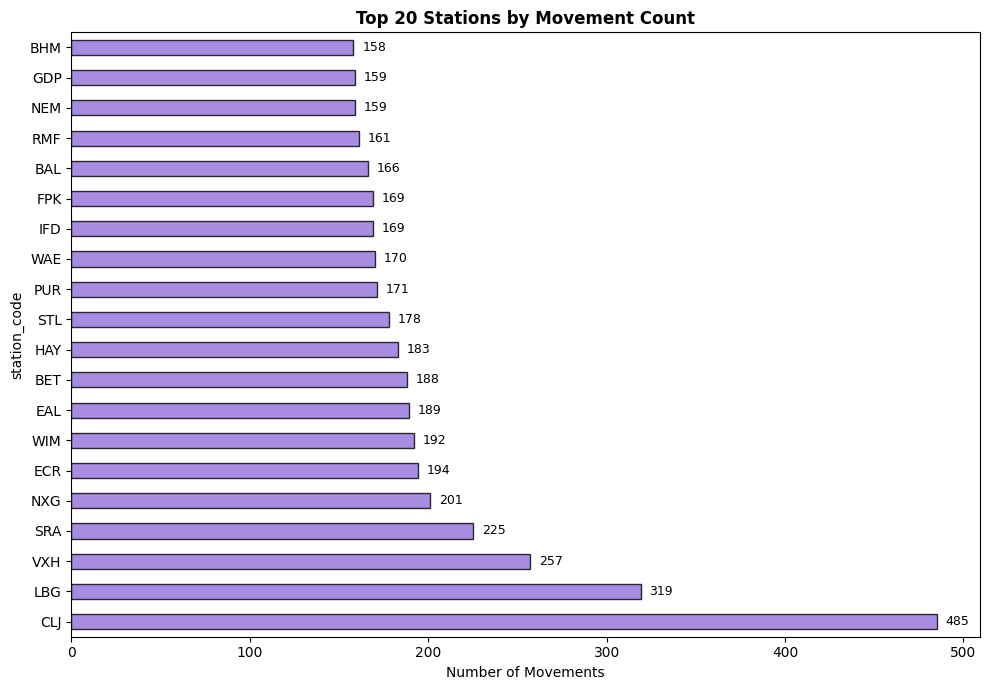

In [18]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)

    plt.figure(figsize=(10, 7))
    top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Movements")
    plt.title("Top 20 Stations by Movement Count", fontweight="bold")
    for i, v in enumerate(top_stations.values):
        plt.text(v + 5, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_02/top_stations_movements.png", dpi=200, bbox_inches="tight")
    plt.show()

## 7. Operational Flags

In [19]:
flag_cols = ["is_delayed", "delay_monitoring_point", "train_terminated"]
for col in flag_cols:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False)
        pct_true = raw_df[col].eq(True).sum() / len(raw_df) * 100
        print(f"=== {col} ===")
        print(vc.to_string())
        print(f"  True rate: {pct_true:.1f}%")
        print()

=== is_delayed ===
is_delayed
0.0    50341
1.0    31855
NaN       77
  True rate: 38.7%

=== delay_monitoring_point ===
delay_monitoring_point
False    40938
True     37883
NaN       3452
  True rate: 46.0%

=== train_terminated ===
train_terminated
False    75666
NaN       3452
True      3155
  True rate: 3.8%



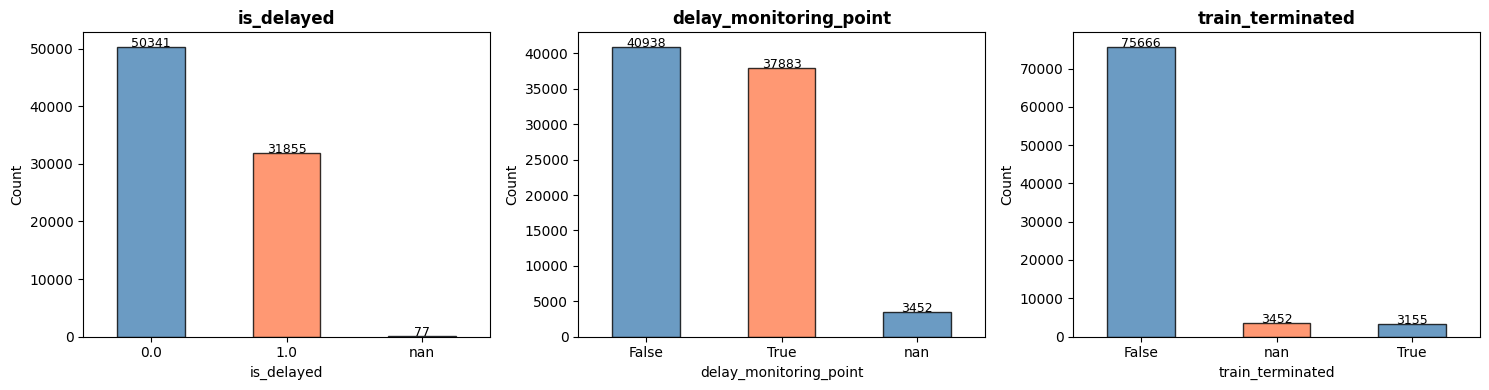

In [20]:
flag_cols_present = [c for c in ["is_delayed", "delay_monitoring_point", "train_terminated"]
                    if c in raw_df.columns]

if flag_cols_present:
    fig, axes = plt.subplots(1, len(flag_cols_present), figsize=(5*len(flag_cols_present), 4))
    if len(flag_cols_present) == 1:
        axes = [axes]

    for ax, col in zip(axes, flag_cols_present):
        vc = raw_df[col].value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black", alpha=0.8)
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for i, v in enumerate(vc.values):
            ax.text(i, v + 5, str(v), ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("figures/eda_02/operational_flags.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. Platform, Route and Direction Distributions

In [21]:
for col in ["platform", "route", "direction", "data_source"]:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False).head(15)
        print(f"=== {col} ===")
        print(vc.to_string())
        print()

=== platform ===
platform
NaN    31585
1      11686
2      11399
1.0     7034
2.0     7021
3       2977
4       2202
3.0     1853
4.0     1343
5        794
5.0      453
6        430
8        353
7        302
6.0      266

=== route ===
route
0.0    30118
1.0    19791
2.0    18057
NaN     8114
3.0     3084
4.0      808
0        799
1        548
2        457
6.0      121
5.0      111
3         86
7.0       81
8.0       34
4         20

=== direction ===
direction
DOWN    33973
UP      33515
NaN     14785

=== data_source ===
data_source
SMART        73338
GPS           3180
TSIA          3065
SDR           2239
NaN            188
TRUST DA       168
TOPS            84
TM ROC 30       10
TM ROC 42        1



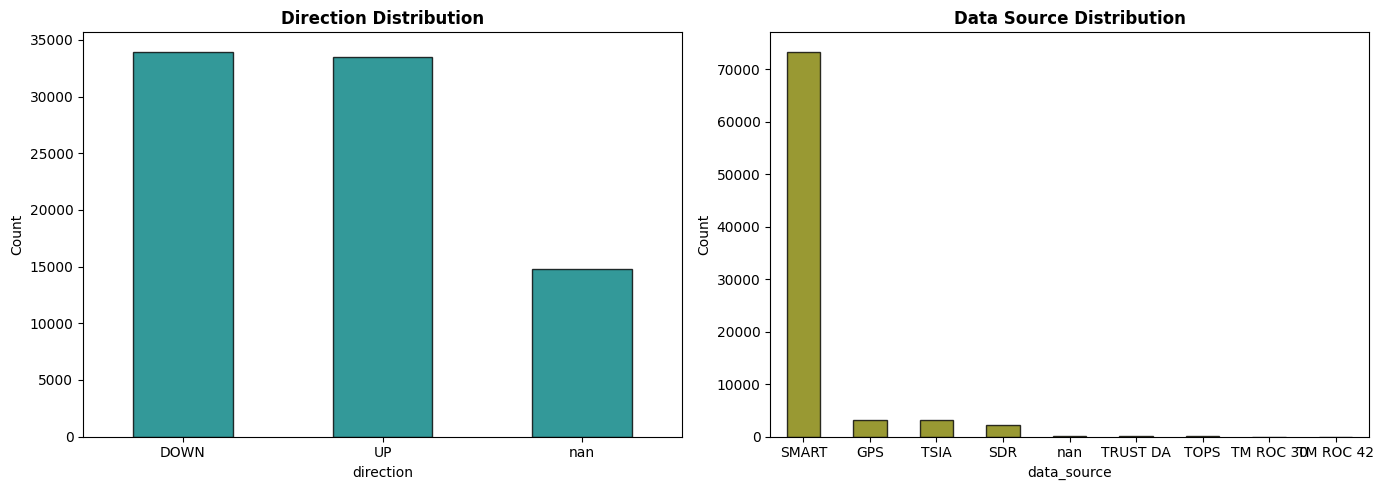

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "direction" in raw_df.columns:
    dir_counts = raw_df["direction"].value_counts(dropna=False)
    dir_counts.plot(kind="bar", ax=axes[0], color="teal", edgecolor="black", alpha=0.8)
    axes[0].set_title("Direction Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

if "data_source" in raw_df.columns:
    ds_counts = raw_df["data_source"].value_counts(dropna=False)
    ds_counts.plot(kind="bar", ax=axes[1], color="olive", edgecolor="black", alpha=0.8)
    axes[1].set_title("Data Source Distribution", fontweight="bold")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_02/platform_direction.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Summary and Cleaned Output

Key findings:
- **41,026 raw rows** retrieved; after dropping rows where both timestamps are null: **39,091 rows**
- `actual_timestamp` and `planned_timestamp` are the critical fields — missing rate documented above
- `timetable_variation` represents the raw operational delay before road-closure conditioning
- Station code match rate reflects STANOX → 3ALPHA lookup coverage
- Night-hour movements are present but sparse; peak hours are morning and evening commute periods


In [23]:
# Drop rows where both timestamps are missing
before = len(raw_df)
clean_df = raw_df.dropna(subset=["actual_timestamp", "planned_timestamp"], how="all")
print(f"Dropped {before - len(clean_df):,} rows (both timestamps null)")
print(f"Final train moments dataset: {len(clean_df):,} rows")


clean_df["platform"] = clean_df["platform"].astype("string")
clean_df["route"] = clean_df["route"].astype("string")

clean_df.to_parquet("./data/processed/train_moments_clean.parquet", index=False)
print("Saved to data/processed/train_moments_clean.parquet")

Dropped 3,452 rows (both timestamps null)
Final train moments dataset: 78,821 rows
Saved to data/processed/train_moments_clean.parquet
